In [1]:
# !pip3 install scikit-learn matplotlib numpy

In [2]:
from sklearn.datasets import make_moons
from matplotlib import pyplot as plt 
import numpy as np 
import random
%matplotlib inline

In [3]:
np.random.seed(1337)
random.seed(1337)

In [4]:
X, Y = make_moons(n_samples = 100, noise = 0.1)

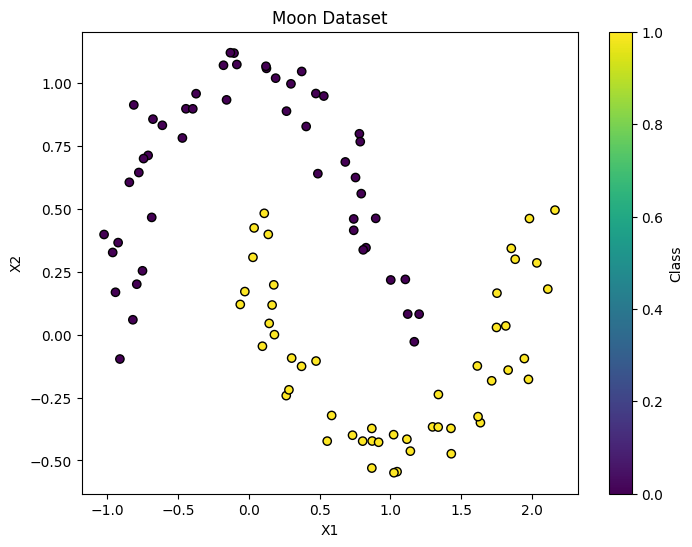

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='viridis', edgecolors='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Moon Dataset')
plt.colorbar(label='Class')
plt.show()

In [6]:
X.dtype

dtype('float64')

In [7]:
type(X)

numpy.ndarray

In [8]:
print(X[:10])

[[ 1.12211461  0.08147717]
 [-0.81882941  0.05879006]
 [ 1.61370966 -0.1246459 ]
 [-0.92300918  0.3652289 ]
 [ 0.14385146  0.04438005]
 [ 0.16447247  0.11738346]
 [ 1.33877062 -0.23800993]
 [ 0.87114861 -0.42271759]
 [ 1.83129946 -0.14104383]
 [ 0.4875712   0.63909283]]


In [9]:
print(Y[:10])

[0 0 1 0 1 1 1 1 1 0]


In [10]:
X.dtype, X[:2], X.shape

(dtype('float64'),
 array([[ 1.12211461,  0.08147717],
        [-0.81882941,  0.05879006]]),
 (100, 2))

In [11]:
Y.dtype, Y[:2], Y.shape

(dtype('int64'), array([0, 0]), (100,))

In [12]:
# x min ? max ? 
X.min(axis = 0), X.max(axis = 0)

(array([-1.02219391, -0.5486393 ]), array([2.16205598, 1.1193894 ]))

In [13]:
# 1st column min value: -1.02 
# 1st column max value: 2.16
# 2nd column min value: -0.54
# 2nd column max value: 1.119

In [14]:
Y.min(), Y.max()

(np.int64(0), np.int64(1))

In [15]:
xs = X.tolist()

In [16]:
len(xs)

100

In [17]:
# for x in xs: 
#     print(x)
#     print(len(x))
#     break
print(len(xs[0]))

2


In [18]:
ys = Y.tolist()

In [19]:
len(ys)

100

In [20]:
type(xs), type(ys)

(list, list)

In [21]:
import torch

In [22]:
xs = torch.tensor(xs)

In [23]:
print(xs[:10])

tensor([[ 1.1221,  0.0815],
        [-0.8188,  0.0588],
        [ 1.6137, -0.1246],
        [-0.9230,  0.3652],
        [ 0.1439,  0.0444],
        [ 0.1645,  0.1174],
        [ 1.3388, -0.2380],
        [ 0.8711, -0.4227],
        [ 1.8313, -0.1410],
        [ 0.4876,  0.6391]])


In [24]:
xs.dtype, xs.shape

(torch.float32, torch.Size([100, 2]))

In [25]:
ys = torch.tensor(ys)

In [26]:
ys.dtype, ys.shape

(torch.int64, torch.Size([100]))

In [27]:
import torch 
import torch.nn as nn

In [28]:
m = nn.Sequential(
    nn.Linear(2, 16), 
    nn.ReLU(), 
    nn.Linear(16, 16), 
    nn.ReLU(), 
    nn.Linear(16, 1)
)

In [29]:
ypreds = m(xs)

In [30]:
ypreds.dtype, ypreds.shape

(torch.float32, torch.Size([100, 1]))

In [31]:
import pprint
pprint.pprint(ypreds[:10])
pprint.pprint(ys[:10])

tensor([[-0.1013],
        [-0.2131],
        [-0.1012],
        [-0.2342],
        [-0.1222],
        [-0.1223],
        [-0.0968],
        [-0.0823],
        [-0.0999],
        [-0.1168]], grad_fn=<SliceBackward0>)
tensor([0, 0, 1, 0, 1, 1, 1, 1, 1, 0])


In [32]:
ys.shape, ypreds.shape

(torch.Size([100]), torch.Size([100, 1]))

In [33]:
ys = ys.view(ys.shape[0], 1)

In [34]:
import pprint
pprint.pprint(ypreds[:10])
pprint.pprint(ys[:10])

tensor([[-0.1013],
        [-0.2131],
        [-0.1012],
        [-0.2342],
        [-0.1222],
        [-0.1223],
        [-0.0968],
        [-0.0823],
        [-0.0999],
        [-0.1168]], grad_fn=<SliceBackward0>)
tensor([[0],
        [0],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [0]])


In [35]:
ys.shape, ypreds.shape

(torch.Size([100, 1]), torch.Size([100, 1]))

In [ ]:
step = 10000
alpha = 0.001
batch_size = 50

xaxis, yaxis = [], []

for i in range(step): 
    r_indx = torch.randperm(len(xs))[:batch_size]
    batch_xs = xs[r_indx]
    batch_ys = ys[r_indx]

    ypreds = m(batch_xs)
    loss = (ypreds - batch_ys).pow(2).sum()
    xaxis.append(i)
    yaxis.append(loss.item())
    if i % 10 == 0: 
        print("loss: ",loss, "step: ", i)

    m.zero_grad()

    loss.backward() 

    with torch.no_grad():
        for p in m.parameters():
            # mini batch stochastic gradient descent
            p.data += (-alpha) * p.grad


loss:  tensor(36.0111, grad_fn=<SumBackward0>) step:  0
loss:  tensor(12.3341, grad_fn=<SumBackward0>) step:  10
loss:  tensor(8.3822, grad_fn=<SumBackward0>) step:  20
loss:  tensor(7.9355, grad_fn=<SumBackward0>) step:  30
loss:  tensor(6.6426, grad_fn=<SumBackward0>) step:  40
loss:  tensor(6.4059, grad_fn=<SumBackward0>) step:  50
loss:  tensor(6.1092, grad_fn=<SumBackward0>) step:  60
loss:  tensor(7.1815, grad_fn=<SumBackward0>) step:  70
loss:  tensor(5.4187, grad_fn=<SumBackward0>) step:  80
loss:  tensor(5.7681, grad_fn=<SumBackward0>) step:  90
loss:  tensor(5.9061, grad_fn=<SumBackward0>) step:  100
loss:  tensor(4.6814, grad_fn=<SumBackward0>) step:  110
loss:  tensor(3.3786, grad_fn=<SumBackward0>) step:  120
loss:  tensor(5.0457, grad_fn=<SumBackward0>) step:  130
loss:  tensor(4.2449, grad_fn=<SumBackward0>) step:  140
loss:  tensor(5.1097, grad_fn=<SumBackward0>) step:  150
loss:  tensor(4.4761, grad_fn=<SumBackward0>) step:  160
loss:  tensor(3.1202, grad_fn=<SumBackwa

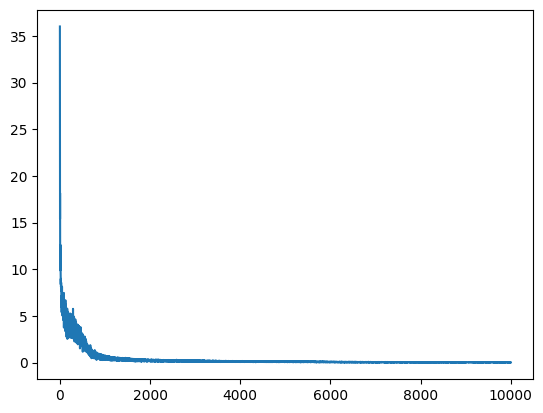

In [37]:
len(xaxis), len(yaxis)
plt.plot(xaxis, yaxis)

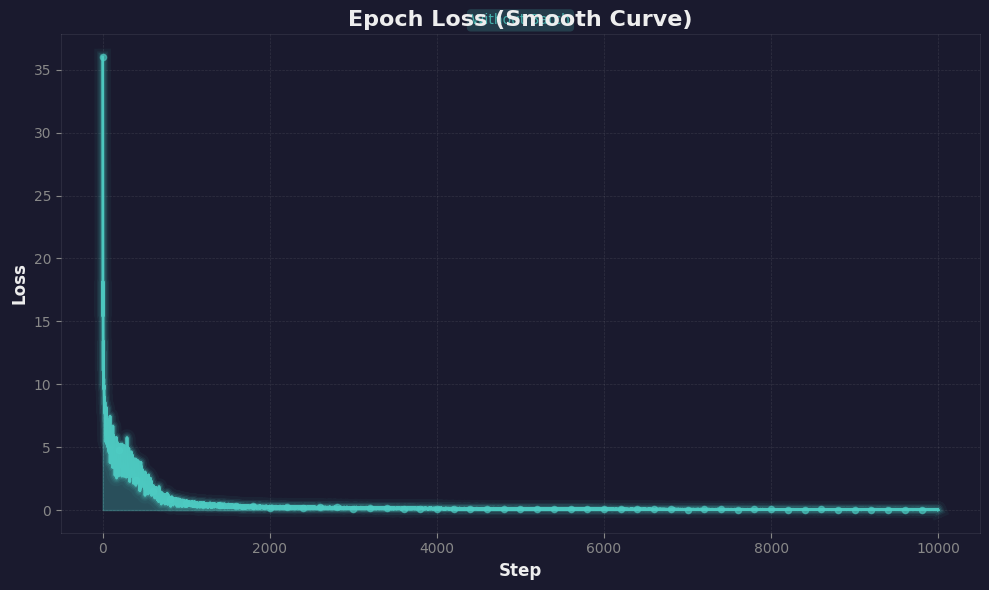

In [38]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

# Create gradient fill under the curve
ax.fill_between(xaxis, yaxis, alpha=0.3, color='#4ecdc4')

# Plot with gradient glow effect similar to the HTML visualization
for lw, alpha in [(12, 0.05), (8, 0.08), (6, 0.12), (4, 0.18), (2, 0.25)]:
    ax.plot(xaxis, yaxis, color='#4ecdc4', linewidth=lw, alpha=alpha)
ax.plot(xaxis, yaxis, color='#4ecdc4', linewidth=2, alpha=0.9)

# Add scatter points at intervals for visual effect
step_interval = len(xaxis) // 50
scatter_x = xaxis[::step_interval]
scatter_y = yaxis[::step_interval]
ax.scatter(scatter_x, scatter_y, color='#4ecdc4', s=20, alpha=0.6, zorder=5)

ax.set_xlabel('Step', color='#eee', fontsize=12, fontweight='600')
ax.set_ylabel('Loss', color='#eee', fontsize=12, fontweight='600')
ax.set_title('Epoch Loss (Smooth Curve)', color='#eee', fontsize=16, fontweight='600')

# Add subtitle/tag
ax.text(0.5, 1.02, 'Without Batch', transform=ax.transAxes, ha='center', 
        fontsize=10, color='#4ecdc4', alpha=0.8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor=(78/255, 205/255, 196/255, 0.2), 
                  edgecolor='none'))

ax.grid(True, color='#ffffff', alpha=0.1, linestyle='--', linewidth=0.5)
ax.spines['bottom'].set_color('#ffffff')
ax.spines['bottom'].set_alpha(0.08)
ax.spines['top'].set_color('#ffffff')
ax.spines['top'].set_alpha(0.08)
ax.spines['left'].set_color('#ffffff')
ax.spines['left'].set_alpha(0.08)
ax.spines['right'].set_color('#ffffff')
ax.spines['right'].set_alpha(0.08)
ax.tick_params(colors='#888')
plt.tight_layout()
plt.show()

In [111]:
# import pickle 
# # weights dump after training
# weights = [p.data for p in m.parameters()] 
# with open("model_weights_torch_without_batch.pkl", 'wb') as f: 
#     pickle.dump(weights, f)


In [157]:
# load model weights 
import pickle
with open("model_weights_torch_without_batch.pkl", 'rb') as f: 
    weights = pickle.load(f)

In [158]:
for p, w in zip(m.parameters(), weights): 
    p.data = w

In [159]:
ypreds = [m(x)for x in xs]
loss = sum((ypred - y) ** 2 for ypred, y in zip(ypreds, ys))


In [160]:
print(loss)

tensor([0.0588], grad_fn=<AddBackward0>)


In [161]:
pprint.pprint(ypreds[:10])
pprint.pprint(ys[:10])

[tensor([-0.0134], grad_fn=<ViewBackward0>),
 tensor([-0.0144], grad_fn=<ViewBackward0>),
 tensor([0.9883], grad_fn=<ViewBackward0>),
 tensor([-0.0099], grad_fn=<ViewBackward0>),
 tensor([0.9918], grad_fn=<ViewBackward0>),
 tensor([0.9996], grad_fn=<ViewBackward0>),
 tensor([0.9219], grad_fn=<ViewBackward0>),
 tensor([0.9827], grad_fn=<ViewBackward0>),
 tensor([0.9931], grad_fn=<ViewBackward0>),
 tensor([0.0056], grad_fn=<ViewBackward0>)]
tensor([[0],
        [0],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [0]])


(-1.6130505552165426, 1.8869494447834574)

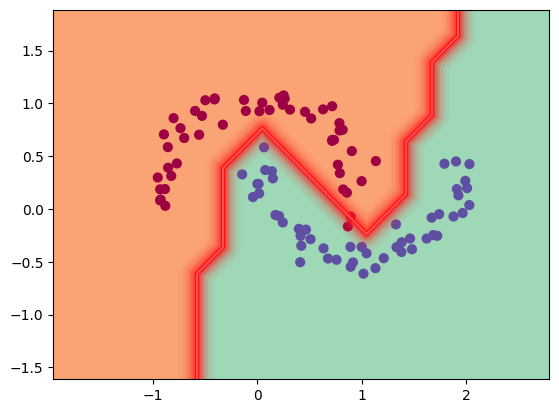

In [164]:
xs2, ys2 = make_moons(n_samples = 100, noise = 0.1)
h = 0.25
x_min, x_max = xs2[:, 0].min() - 1, xs2[:, 0].max() + 1
y_min, y_max = xs2[:, 1].min() - 1, xs2[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = torch.tensor(Xmesh, dtype=torch.float32)
scores = m(inputs)
Z = (scores.data > 0.5).numpy()
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)

# Add glowing neon red decision boundary with enhanced glow
# Outer glow layers (more layers, wider spread, brighter colors)
for lw, alpha in [(25, 0.05), (20, 0.08), (16, 0.12), (12, 0.18), (9, 0.25), (6, 0.35), (4, 0.5)]:
    plt.contour(xx, yy, Z, levels=[0.5], colors=['#ff2222'], linewidths=lw, alpha=alpha)

# Core bright red line
contour = plt.contour(xx, yy, Z, levels=[0.5], colors=['#ff0000'], linewidths=2.5)
# Inner bright highlight
plt.contour(xx, yy, Z, levels=[0.5], colors=['#ff6666'], linewidths=1.5, alpha=0.8)

plt.scatter(xs2[:, 0], xs2[:, 1], c=ys2, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())